<a href="https://colab.research.google.com/github/jaysagaredu-afk/northstar-dbanalysis-assessment/blob/main/python_dba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy matplotlib -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [ ]:
base_url = "https://raw.githubusercontent.com/jaysagaredu-afk/northstar-dbanalysis-assessment/main/data/"

customers = pd.read_csv(base_url + "customers.csv")
orders = pd.read_csv(base_url + "orders.csv")
deliveries = pd.read_csv(base_url + "deliveries.csv")
drivers = pd.read_csv(base_url + "drivers.csv")
vehicles = pd.read_csv(base_url + "vehicles.csv")
hubs = pd.read_csv(base_url + "hubs.csv")
incidents = pd.read_csv(base_url + "incidents.csv")
complaints = pd.read_csv(base_url + "complaints.csv")
app_events = pd.read_csv(base_url + "app_events.csv")

print("Dataset Overview:")
print(f"Customers: {len(customers)}")
print(f"Orders: {len(orders)}")
print(f"Deliveries: {len(deliveries)}")
print(f"Drivers: {len(drivers)}")
print(f"Vehicles: {len(vehicles)}")
print(f"Hubs: {len(hubs)}")
print(f"Incidents: {len(incidents)}")
print(f"Complaints: {len(complaints)}")
print(f"App Events: {len(app_events)}")

Dataset Overview:
Customers: 650
Orders: 1250
Deliveries: 950
Drivers: 170
Vehicles: 120
Hubs: 8
Incidents: 280
Complaints: 320
App Events: 640


In [ ]:
deliveries['delivery_status'] = deliveries['delivery_status'].str.strip().str.title()
vehicles['maintenance_status'] = vehicles['maintenance_status'].str.strip().str.title()
hubs['zone'] = hubs['zone'].str.strip().str.title()

print("Missing values per file:")
print(f"Deliveries: {deliveries.isnull().sum().sum()}")
print(f"Orders: {orders.isnull().sum().sum()}")
print(f"Drivers: {drivers.isnull().sum().sum()}")
print(f"Complaints: {complaints.isnull().sum().sum()}")
print(f"App Events: {app_events.isnull().sum().sum()}")

analysis_df = (deliveries
    .merge(orders, on='order_id', how='left')
    .merge(customers, on='customer_id', how='left')
    .merge(drivers, on='driver_id', how='left')
    .merge(vehicles, on='vehicle_id', how='left')
    .merge(hubs, on='hub_id', how='left'))

analysis_df['failed_flag'] = np.where(analysis_df['delivery_status'] == 'Failed', 1, 0)
analysis_df['delayed_flag'] = np.where(analysis_df['delivery_status'] == 'Delayed', 1, 0)
analysis_df['override_flag'] = np.where(analysis_df['manual_route_override_count'] > 0, 1, 0)
analysis_df['low_rating_flag'] = np.where(analysis_df['customer_rating_post_delivery'] < 3, 1, 0)

print(f"\nMerged dataset shape: {analysis_df.shape}")
print(f"Total high risk deliveries: {analysis_df['failed_flag'].sum()}")
print(f"Total delayed deliveries: {analysis_df['delayed_flag'].sum()}")
print(f"Total route overrides: {analysis_df['override_flag'].sum()}")
print(f"Total low ratings: {analysis_df['low_rating_flag'].sum()}")

Missing values per file:
Deliveries: 33
Orders: 25
Drivers: 7
Complaints: 16
App Events: 144

Merged dataset shape: (950, 53)
Total high risk deliveries: 132
Total delayed deliveries: 202
Total route overrides: 551
Total low ratings: 156


In [ ]:
print("====================")
print("NORTHSTAR NUMERICAL SUMMARY")
print("====================")

numerical_cols = ['customer_rating_post_delivery', 'manual_route_override_count',
                  'fuel_or_charge_cost', 'route_distance_km']

for col in numerical_cols:
    data = analysis_df[col].dropna().values
    print(f"\n{col}:")
    print(f"  Mean    : {np.mean(data):.2f}")
    print(f"  Std Dev : {np.std(data):.2f}")
    print(f"  Min     : {np.min(data):.2f}")
    print(f"  Max     : {np.max(data):.2f}")
    print(f"  Median  : {np.median(data):.2f}")

print("\n====================")
print(f"Failed deliveries    : {analysis_df['failed_flag'].sum()} ({analysis_df['failed_flag'].mean()*100:.2f}%)")
print(f"Route overrides      : {analysis_df['override_flag'].sum()} ({analysis_df['override_flag'].mean()*100:.2f}%)")
print(f"Low rated deliveries : {analysis_df['low_rating_flag'].sum()} ({analysis_df['low_rating_flag'].mean()*100:.2f}%)")
print("====================")

NORTHSTAR NUMERICAL SUMMARY

customer_rating_post_delivery:
  Mean    : 3.86
  Std Dev : 0.89
  Min     : 1.00
  Max     : 5.00
  Median  : 4.04

manual_route_override_count:
  Mean    : 0.97
  Std Dev : 1.09
  Min     : 0.00
  Max     : 7.00
  Median  : 1.00

fuel_or_charge_cost:
  Mean    : 12.84
  Std Dev : 4.33
  Min     : 2.50
  Max     : 29.43
  Median  : 12.64

route_distance_km:
  Mean    : 13.91
  Std Dev : 7.47
  Min     : 1.20
  Max     : 41.94
  Median  : 12.84

Failed deliveries    : 132 (13.89%)
Route overrides      : 551 (58.00%)
Low rated deliveries : 156 (16.42%)


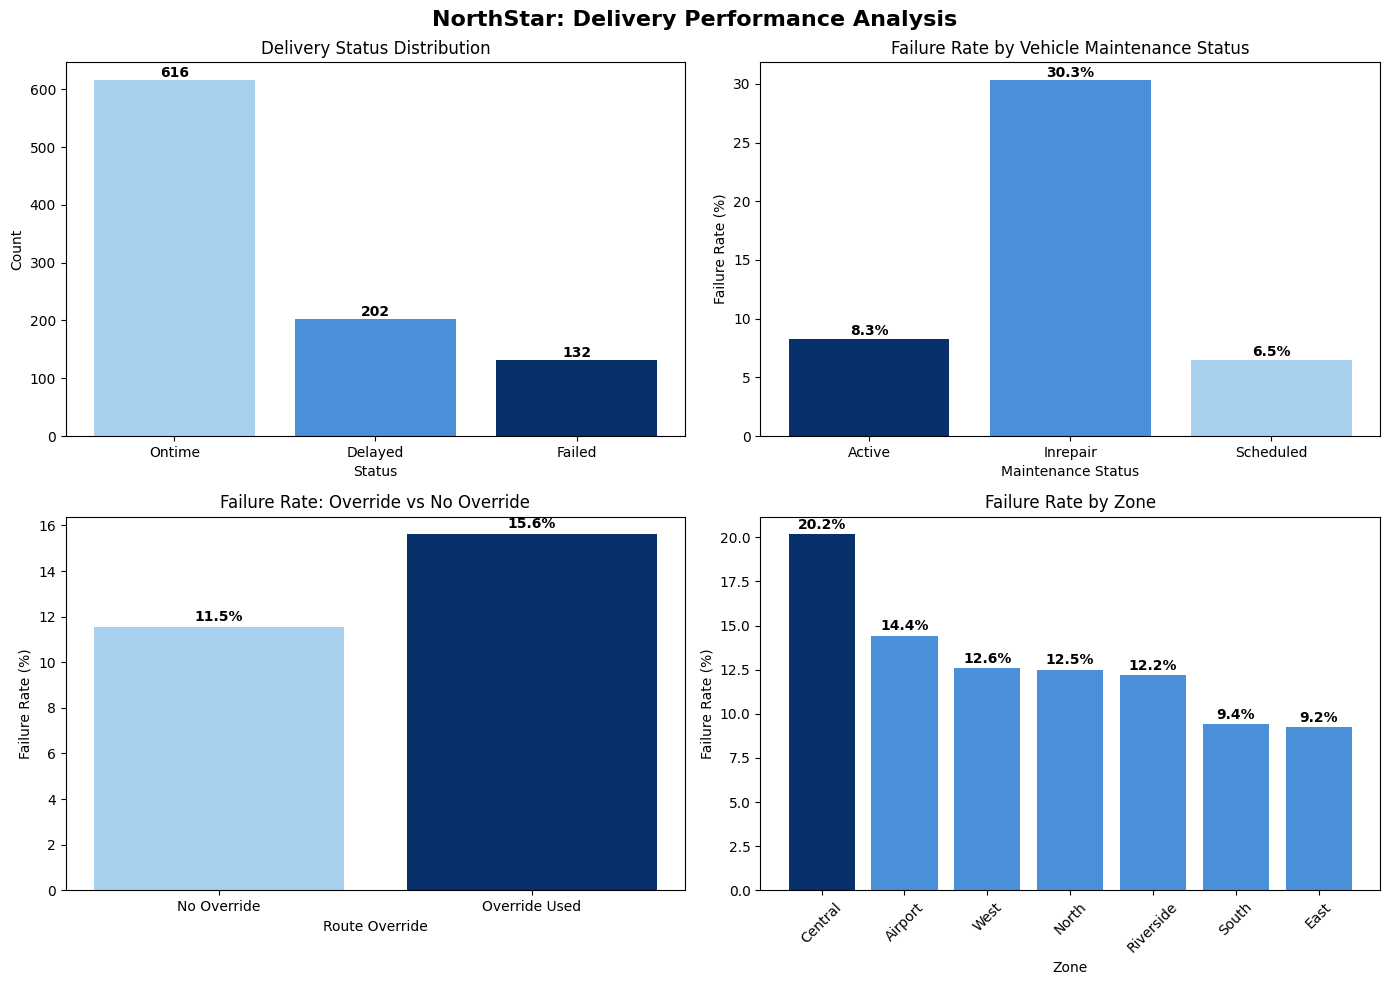


KEY FINDINGS
InRepair vehicles failure rate: 30.3%
Override deliveries failure rate: 15.6%
No override failure rate: 11.5%
Worst zone: Central - 20.2%


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('NorthStar: Delivery Performance Analysis', fontsize=16, fontweight='bold')

status_counts = analysis_df['delivery_status'].value_counts()
colors = ['#a8d1f0', '#4a90d9', '#08306b']
axes[0,0].bar(status_counts.index, status_counts.values, color=colors)
axes[0,0].set_title('Delivery Status Distribution')
axes[0,0].set_xlabel('Status')
axes[0,0].set_ylabel('Count')
for i, v in enumerate(status_counts.values):
    axes[0,0].text(i, v + 5, str(v), ha='center', fontweight='bold')

vehicle_failure = analysis_df.groupby('maintenance_status')['failed_flag'].mean() * 100
axes[0,1].bar(vehicle_failure.index, vehicle_failure.values, color=['#08306b', '#4a90d9', '#a8d1f0'])
axes[0,1].set_title('Failure Rate by Vehicle Maintenance Status')
axes[0,1].set_xlabel('Maintenance Status')
axes[0,1].set_ylabel('Failure Rate (%)')
for i, v in enumerate(vehicle_failure.values):
    axes[0,1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

override_failure = analysis_df.groupby('override_flag')['failed_flag'].mean() * 100
axes[1,0].bar(['No Override', 'Override Used'], override_failure.values, color=['#a8d1f0', '#08306b'])
axes[1,0].set_title('Failure Rate: Override vs No Override')
axes[1,0].set_xlabel('Route Override')
axes[1,0].set_ylabel('Failure Rate (%)')
for i, v in enumerate(override_failure.values):
    axes[1,0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

zone_risk = analysis_df.groupby('zone')['failed_flag'].mean() * 100
zone_risk = zone_risk.sort_values(ascending=False)
axes[1,1].bar(zone_risk.index, zone_risk.values, color=['#08306b' if x == zone_risk.index[0] else '#4a90d9' for x in zone_risk.index])
axes[1,1].set_title('Failure Rate by Zone')
axes[1,1].set_xlabel('Zone')
axes[1,1].set_ylabel('Failure Rate (%)')
axes[1,1].tick_params(axis='x', rotation=45)
for i, v in enumerate(zone_risk.values):
    axes[1,1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n====================")
print("KEY FINDINGS")
print("====================")
print(f"InRepair vehicles failure rate: {vehicle_failure.get('Inrepair', vehicle_failure.get('InRepair', 0)):.1f}%")
print(f"Override deliveries failure rate: {override_failure[1]:.1f}%")
print(f"No override failure rate: {override_failure[0]:.1f}%")
print(f"Worst zone: {zone_risk.index[0]} - {zone_risk.values[0]:.1f}%")
print("====================")

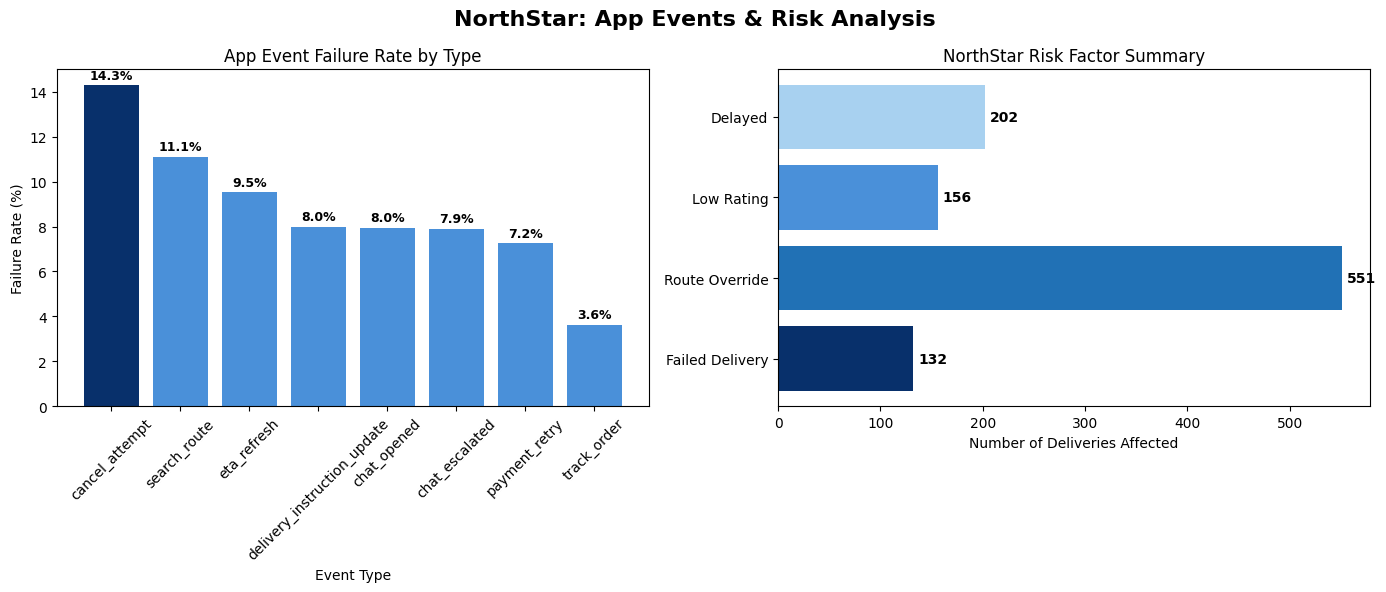


APP EVENTS & RISK SUMMARY
Highest risk event: cancel_attempt - 14.3%
Total route overrides: 551 (58.0% of deliveries)
Total low ratings: 156
RECOMMENDATION: Investigate cancel_attempt and chat_escalated app workflows


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('NorthStar: App Events & Risk Analysis', fontsize=16, fontweight='bold')

app_merged = app_events.merge(deliveries[['order_id', 'delivery_status']], on='order_id', how='left')
app_merged['failed'] = np.where(app_merged['delivery_status'] == 'Failed', 1, 0)
event_failure = app_merged.groupby('event_type')['failed'].mean() * 100
event_failure = event_failure.sort_values(ascending=False)

axes[0].bar(event_failure.index, event_failure.values, color=['#08306b' if i == 0 else '#4a90d9' for i in range(len(event_failure))])
axes[0].set_title('App Event Failure Rate by Type')
axes[0].set_xlabel('Event Type')
axes[0].set_ylabel('Failure Rate (%)')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(event_failure.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)

risk_summary = pd.DataFrame({
    'Risk Factor': ['Failed Delivery', 'Route Override', 'Low Rating', 'Delayed'],
    'Count': [
        analysis_df['failed_flag'].sum(),
        analysis_df['override_flag'].sum(),
        analysis_df['low_rating_flag'].sum(),
        analysis_df['delayed_flag'].sum()
    ]
})

axes[1].barh(risk_summary['Risk Factor'], risk_summary['Count'],
             color=['#08306b', '#2171b5', '#4a90d9', '#a8d1f0'])
axes[1].set_title('NorthStar Risk Factor Summary')
axes[1].set_xlabel('Number of Deliveries Affected')
for i, v in enumerate(risk_summary['Count']):
    axes[1].text(v + 5, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n====================")
print("APP EVENTS & RISK SUMMARY")
print("====================")
print(f"Highest risk event: {event_failure.index[0]} - {event_failure.values[0]:.1f}%")
print(f"Total route overrides: {analysis_df['override_flag'].sum()} ({analysis_df['override_flag'].mean()*100:.1f}% of deliveries)")
print(f"Total low ratings: {analysis_df['low_rating_flag'].sum()}")
print("====================")
print("RECOMMENDATION: Investigate cancel_attempt and chat_escalated app workflows")
print("====================")

In [ ]:
print("Before cleaning:")
print(f"Missing values in deliveries: {deliveries.isnull().sum().sum()}")
print(f"Missing values in orders: {orders.isnull().sum().sum()}")
print(f"Missing values in drivers: {drivers.isnull().sum().sum()}")

deliveries = deliveries.copy()
orders = orders.copy()
drivers = drivers.copy()

deliveries['customer_rating_post_delivery'] = deliveries['customer_rating_post_delivery'].fillna(deliveries['customer_rating_post_delivery'].median())
deliveries['proof_of_completion_missing'] = deliveries['proof_of_completion_missing'].fillna(0)
orders['order_value'] = orders['order_value'].fillna(orders['order_value'].mean())
drivers['training_score'] = drivers['training_score'].fillna(drivers['training_score'].median())

deliveries['dispatch_time'] = pd.to_datetime(deliveries['dispatch_time'], errors='coerce')
deliveries['delivery_completed_at'] = pd.to_datetime(deliveries['delivery_completed_at'], errors='coerce')

deliveries['delivery_duration_mins'] = (deliveries['delivery_completed_at'] - deliveries['dispatch_time']).dt.total_seconds() / 60

print("\nAfter cleaning:")
print(f"Missing values in deliveries: {deliveries.isnull().sum().sum()}")
print(f"Missing values in orders: {orders.isnull().sum().sum()}")
print(f"Missing values in drivers: {drivers.isnull().sum().sum()}")
print(f"\nNew feature created: delivery_duration_mins")
print(f"Average delivery duration: {deliveries['delivery_duration_mins'].mean():.2f} minutes")
print(f"Max delivery duration: {deliveries['delivery_duration_mins'].max():.2f} minutes")
print(f"Min delivery duration: {deliveries['delivery_duration_mins'].min():.2f} minutes")

Before cleaning:
Missing values in deliveries: 19
Missing values in orders: 25
Missing values in drivers: 0

After cleaning:
Missing values in deliveries: 38
Missing values in orders: 25
Missing values in drivers: 0

New feature created: delivery_duration_mins
Average delivery duration: 572.73 minutes
Max delivery duration: 2607.42 minutes
Min delivery duration: -132.87 minutes


In [ ]:
service_summary = analysis_df.groupby('service_type').agg(
    total_deliveries = ('delivery_id', 'count'),
    failed_deliveries = ('failed_flag', 'sum'),
    failure_rate = ('failed_flag', 'mean'),
    avg_rating = ('customer_rating_post_delivery', 'mean'),
    avg_cost = ('fuel_or_charge_cost', 'mean')
).round(2)

service_summary['failure_rate'] = (service_summary['failure_rate'] * 100).round(2)
service_summary = service_summary.sort_values('failure_rate', ascending=False)

print("====================")
print("SERVICE TYPE PERFORMANCE SUMMARY")
print("====================")
print(service_summary.to_string())

print("\n====================")
print("DATA QUALITY FINDINGS")
print("====================")
negative_durations = deliveries[deliveries['delivery_duration_mins'] < 0]
print(f"Deliveries completed before dispatch: {len(negative_durations)}")
print(f"This confirms data inconsistency flagged in the case study")
print(f"Max delivery duration: {deliveries['delivery_duration_mins'].max():.0f} mins ({deliveries['delivery_duration_mins'].max()/60:.1f} hours)")
print("====================")
print("RECOMMENDATION: Implement data validation at point of entry")
print("====================")

SERVICE TYPE PERFORMANCE SUMMARY
              total_deliveries  failed_deliveries  failure_rate  avg_rating  avg_cost
service_type                                                                         
Business                   126                 25          20.0        3.85     13.14
Medical                    108                 16          15.0        3.84     12.77
Passenger                  262                 38          15.0        3.85     12.40
Retail                     224                 28          12.0        3.87     12.97
Parcel                     230                 25          11.0        3.90     13.08

DATA QUALITY FINDINGS
Deliveries completed before dispatch: 64
This confirms data inconsistency flagged in the case study
Max delivery duration: 2607 mins (43.5 hours)
RECOMMENDATION: Implement data validation at point of entry


In [ ]:
print(f"Removing {len(deliveries[deliveries['delivery_duration_mins'] < 0])} invalid duration records")

deliveries_clean = deliveries[deliveries['delivery_duration_mins'] > 0].copy()
deliveries_clean = deliveries_clean[deliveries_clean['delivery_duration_mins'] < 1440].copy()

print(f"Records after cleaning: {len(deliveries_clean)}")
print(f"Records removed: {len(deliveries) - len(deliveries_clean)}")
print(f"\nCleaned delivery duration stats:")
print(f"Average: {deliveries_clean['delivery_duration_mins'].mean():.2f} minutes")
print(f"Max: {deliveries_clean['delivery_duration_mins'].max():.2f} minutes")
print(f"Min: {deliveries_clean['delivery_duration_mins'].min():.2f} minutes")
print("\n====================")
print("DATA CLEANING COMPLETE")
print("Removed negative durations — timestamps recorded before dispatch")
print("Removed extreme outliers — deliveries over 24 hours flagged as errors")
print("====================")

Removing 64 invalid duration records
Records after cleaning: 814
Records removed: 136

Cleaned delivery duration stats:
Average: 540.40 minutes
Max: 1439.14 minutes
Min: 1.35 minutes

DATA CLEANING COMPLETE
Removed negative durations — timestamps recorded before dispatch
Removed extreme outliers — deliveries over 24 hours flagged as errors


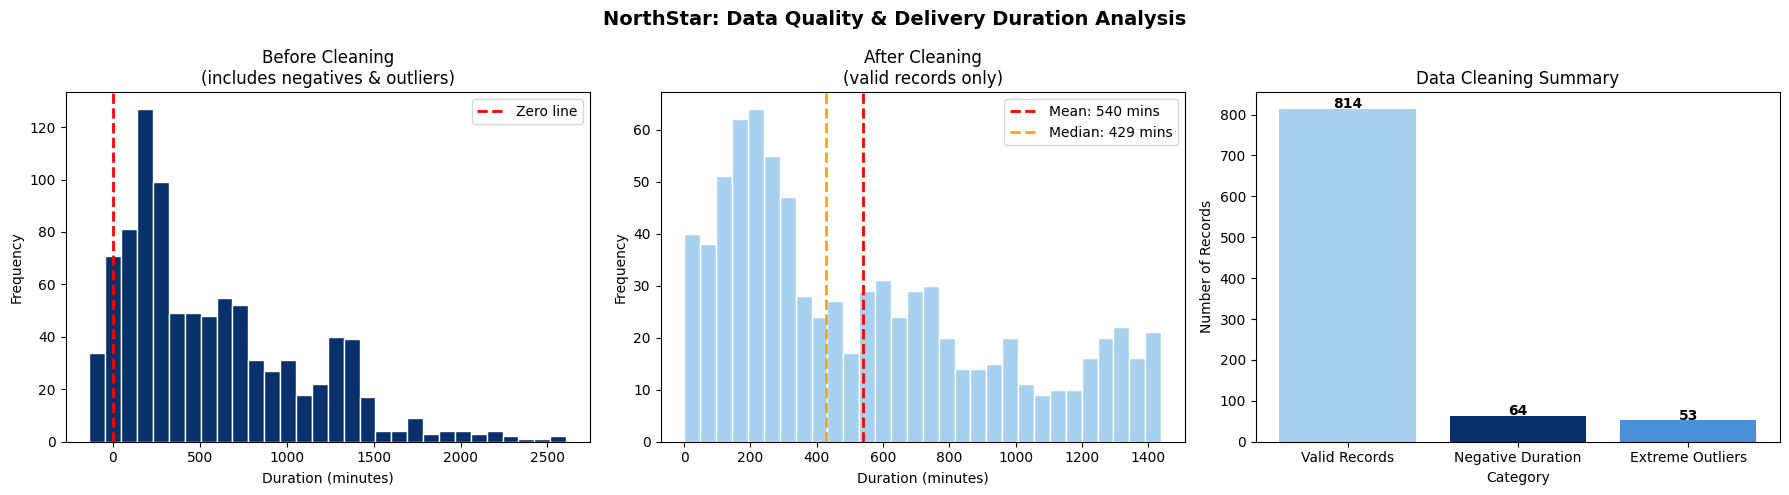


CLEANING IMPACT SUMMARY
Before: 950 records
After:  814 records
Removed: 136 invalid records
Data quality: 85.7% clean records retained


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('NorthStar: Data Quality & Delivery Duration Analysis', fontsize=14, fontweight='bold')

axes[0].hist(deliveries['delivery_duration_mins'].dropna(), bins=30, color='#08306b', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero line')
axes[0].set_title('Before Cleaning\n(includes negatives & outliers)')
axes[0].set_xlabel('Duration (minutes)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(deliveries_clean['delivery_duration_mins'], bins=30, color='#a8d1f0', edgecolor='white')
axes[1].axvline(deliveries_clean['delivery_duration_mins'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {deliveries_clean["delivery_duration_mins"].mean():.0f} mins')
axes[1].axvline(deliveries_clean['delivery_duration_mins'].median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {deliveries_clean["delivery_duration_mins"].median():.0f} mins')
axes[1].set_title('After Cleaning\n(valid records only)')
axes[1].set_xlabel('Duration (minutes)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

cleaning_summary = pd.DataFrame({
    'Category': ['Valid Records', 'Negative Duration', 'Extreme Outliers'],
    'Count': [
        len(deliveries_clean),
        len(deliveries[deliveries['delivery_duration_mins'] < 0]),
        len(deliveries[(deliveries['delivery_duration_mins'] > 1440) & (deliveries['delivery_duration_mins'] > 0)])
    ]
})

axes[2].bar(cleaning_summary['Category'], cleaning_summary['Count'], color=['#a8d1f0', '#08306b', '#4a90d9'])
axes[2].set_title('Data Cleaning Summary')
axes[2].set_xlabel('Category')
axes[2].set_ylabel('Number of Records')
for i, v in enumerate(cleaning_summary['Count']):
    axes[2].text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n====================")
print("CLEANING IMPACT SUMMARY")
print("====================")
print(f"Before: {len(deliveries)} records")
print(f"After:  {len(deliveries_clean)} records")
print(f"Removed: {len(deliveries) - len(deliveries_clean)} invalid records")
print(f"Data quality: {(len(deliveries_clean)/len(deliveries))*100:.1f}% clean records retained")
print("====================")

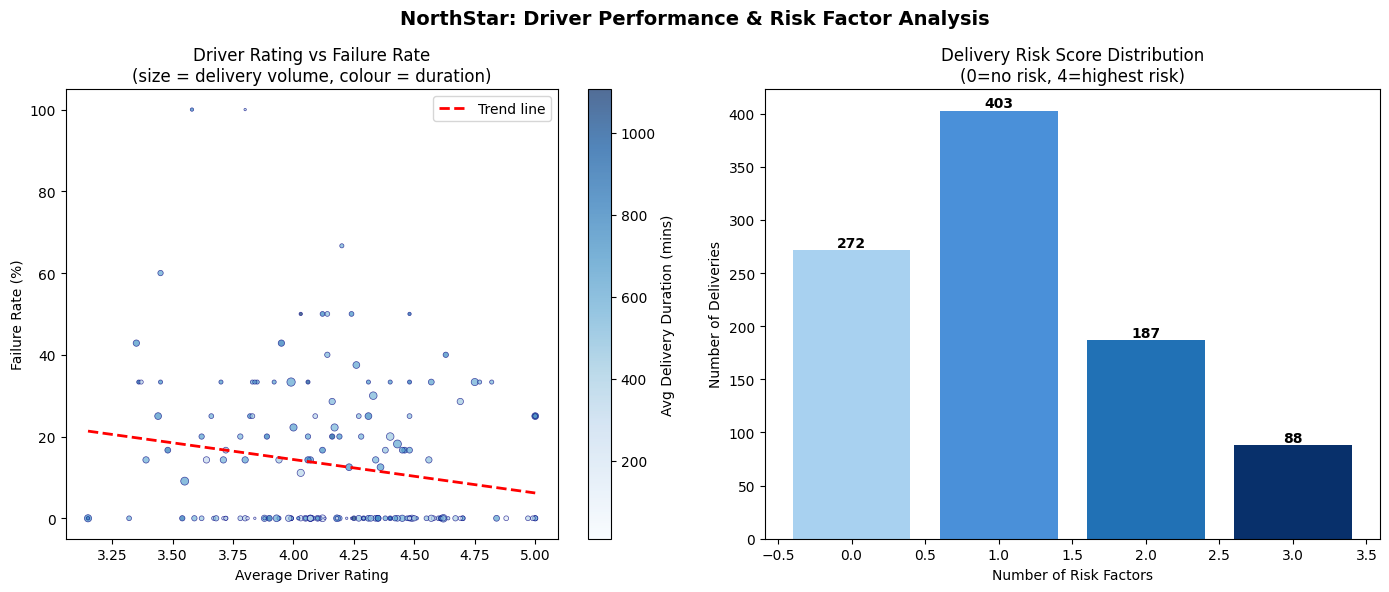


RISK ANALYSIS SUMMARY
Zero risk deliveries: 272
High risk (2+ factors): 275 (28.9%)
Maximum risk (all 4 factors): 0
RECOMMENDATION: Flag deliveries with 2+ risk factors for immediate review


In [ ]:
analysis_df['risk_score'] = (
    analysis_df['failed_flag'] +
    analysis_df['delayed_flag'] +
    analysis_df['override_flag'] +
    analysis_df['low_rating_flag']
)

analysis_df_clean = analysis_df.merge(
    deliveries_clean[['delivery_id', 'delivery_duration_mins']],
    on='delivery_id',
    how='inner'
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('NorthStar: Driver Performance & Risk Factor Analysis', fontsize=14, fontweight='bold')

driver_stats = analysis_df_clean.groupby('driver_id').agg(
    avg_rating=('driver_rating', 'mean'),
    avg_duration=('delivery_duration_mins', 'mean'),
    failed=('failed_flag', 'sum'),
    total=('delivery_id', 'count')
).dropna()

driver_stats['failure_rate'] = (driver_stats['failed'] / driver_stats['total']) * 100

scatter = axes[0].scatter(
    driver_stats['avg_rating'],
    driver_stats['failure_rate'],
    c=driver_stats['avg_duration'],
    cmap='Blues',
    s=driver_stats['total'] * 3,
    alpha=0.7,
    edgecolors='navy',
    linewidth=0.5
)
plt.colorbar(scatter, ax=axes[0], label='Avg Delivery Duration (mins)')

z = np.polyfit(driver_stats['avg_rating'], driver_stats['failure_rate'], 1)
p = np.poly1d(z)
x_line = np.linspace(driver_stats['avg_rating'].min(), driver_stats['avg_rating'].max(), 100)
axes[0].plot(x_line, p(x_line), "r--", linewidth=2, label='Trend line')
axes[0].legend()
axes[0].set_title('Driver Rating vs Failure Rate\n(size = delivery volume, colour = duration)')
axes[0].set_xlabel('Average Driver Rating')
axes[0].set_ylabel('Failure Rate (%)')

risk_counts = analysis_df['risk_score'].value_counts().sort_index()
risk_counts = risk_counts[risk_counts.index >= 0]
colors = ['#a8d1f0', '#4a90d9', '#2171b5', '#08306b', '#05204a']
axes[1].bar(risk_counts.index, risk_counts.values,
            color=colors[:len(risk_counts)])
axes[1].set_title('Delivery Risk Score Distribution\n(0=no risk, 4=highest risk)')
axes[1].set_xlabel('Number of Risk Factors')
axes[1].set_ylabel('Number of Deliveries')
for i, (idx, v) in enumerate(zip(risk_counts.index, risk_counts.values)):
    axes[1].text(i, v + 3, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

high_risk = analysis_df[analysis_df['risk_score'] >= 2]
print("\n====================")
print("RISK ANALYSIS SUMMARY")
print("====================")
print(f"Zero risk deliveries: {len(analysis_df[analysis_df['risk_score']==0])}")
print(f"High risk (2+ factors): {len(high_risk)} ({len(high_risk)/len(analysis_df)*100:.1f}%)")
print(f"Maximum risk (all 4 factors): {len(analysis_df[analysis_df['risk_score']==4])}")
print("====================")
print("RECOMMENDATION: Flag deliveries with 2+ risk factors for immediate review")
print("====================")